In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.5"

from calvin_env.envs.play_table_env import PlayTableSimEnv

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Apr 29 2026 08:57:25
/home/hppeng/gatech/calvin/calvin_env/calvin_env/envs/play_table_env.py:292: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../../conf", config_name="config_data_collection")


In [2]:
import calvin_env
from hydra import initialize, compose
import hydra

with initialize(config_path=f"../calvin_env/conf/"):
    cfg = compose(config_name="config_data_collection.yaml", overrides=["cameras=static_and_gripper"])
    cfg.env["use_egl"] = False
    cfg.env["show_gui"] = False
    cfg.env["use_vr"] = False
    cfg.env["use_scene_info"] = True
    print(cfg.env)

env = hydra.utils.instantiate(cfg.env)

/tmp/ipykernel_17148/3854874617.py:5: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=f"../calvin_env/conf/"):
/home/hppeng/gatech/calvin/.venv/lib/python3.12/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config_data_collection.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
/home/hppeng/gatech/calvin/.venv/lib/python3.12/site-packages/hydra/core/default_element.py:124: UserWarning: In 'vr_input/vr_controller/vive': Usage of deprecated keyword in package header '# @package _group_'.
See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/changes_to_package_header for more information
  deprecation_warning(


{'_target_': 'calvin_env.envs.play_table_env.PlayTableSimEnv', '_recursive_': False, 'cameras': '${cameras}', 'seed': 0, 'bullet_time_step': 240.0, 'use_vr': False, 'show_gui': False, 'robot_cfg': '${robot}', 'scene_cfg': '${scene}', 'use_scene_info': True, 'use_egl': False, 'control_freq': 30}


In [3]:
from openpi.policies import policy_config as _policy_config
from openpi.training import config as _config

import pathlib
def create_pi05(model_name, checkpoint_dir: str, assets_dir=None):
    vla_config = _config.get_config(model_name)
    checkpoint_dir = pathlib.Path(checkpoint_dir).resolve()

    norm_stats = None
    if assets_dir is not None:
        data_config = vla_config.data.create(vla_config.assets_dirs, vla_config.model)
        if data_config.asset_id is not None:
            from openpi.training import checkpoints as _checkpoints
            assets_path = pathlib.Path(assets_dir).resolve()
            norm_stats = _checkpoints.load_norm_stats(assets_path, data_config.asset_id)

    return _policy_config.create_trained_skill_reasoning_policy(
        vla_config,
        checkpoint_dir,
        norm_stats=norm_stats,
        force_initial_reasoning=False
    )

import openpi
openpi_root = pathlib.Path(openpi.__file__).resolve().parent.parent.parent
model_name = "pi05_calvin"
checkpoint_dir = openpi_root / "checkpoints" / "pi05_calvin" / "pi05_calvin" / "99999"
assets_dir = openpi_root / "assets" / "pi05_calvin"

model = create_pi05(model_name, checkpoint_dir, assets_dir)


/home/hppeng/gatech/calvin/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def prompt_from_obs(obs, prompt):
    return {
        "observation/image": obs['rgb_obs']['rgb_static'].astype(np.uint8),
        "observation/wrist_image": obs['rgb_obs']['rgb_gripper'].astype(np.uint8),
        "observation/state": obs['robot_obs'],
        "prompt": prompt,
        "thought": [prompt],
        "mode": "acting"
    }

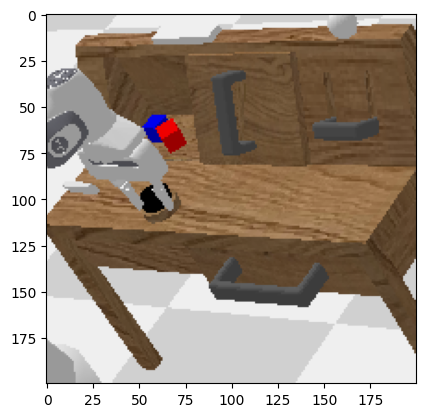

In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt
#from google.colab.patches import cv2_imshow
observation = env.reset()

plt.figure(0)
plt.imshow(observation['rgb_obs']['rgb_static'])
plt.show()

In [14]:
task = "turn on the lightbulb"

prompt = prompt_from_obs(observation, task)
vla_output = model.infer(prompt)
print(vla_output)

action_idx = 0
#The observation is given as a dictionary with different values
images = []
for i in range(120):
    # The action consists in a pose displacement (position and orientation)
    if action_idx == len(vla_output['actions']):
        prompt = prompt_from_obs(observation, task)
        vla_output = model.infer(prompt)
        action_idx = 0
    action = vla_output['actions'][action_idx].copy()
    print(action[-1])
    if action[-1] < 0:
        action[-1] = -1
    else:
        action[-1] = 1
    action_idx += 1
    observation, reward, done, info = env.step(action)
    rgb = np.array(env.render(mode="rgb_array"), dtype=np.uint8).copy()
    images.append(rgb)
#     plt.figure(i)
#     plt.clf()
#     plt.imshow(rgb)

inputs -------------------> ['turn on the lightbulb']
mode acting now...
{'state': array([-1.8578115e-01,  1.9266866e-03,  4.7930574e-01,  3.1046603e+00,
       -1.3004608e-01,  1.9326731e+00,  4.0548790e-02, -5.2729064e-01,
        7.5793207e-01,  1.8446990e+00, -2.3983867e+00, -8.3694160e-01,
        2.1255705e+00,  6.8717986e-01, -1.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
      dtype=float32), 'actions': array([[ 0.03859797, -0.16703105, -0.1261473 ,  0.0691369 ,  0.16626841,
        -0.1850816 , -1.0020133 ],
       [ 0.03097218, -0.12454402, -0.08961928,  0.08207732,  0.16462672,
        -0.17016378, -0.9985142 ],
       [ 0.05091429, -0.07271457,  0.02901554,  0.07983178,  0.04389405,
        -0.24738312,  0.99

In [6]:
from calvin_agent.evaluation.multistep_sequences import get_sequences
from calvin_agent.evaluation.utils import get_env_state_for_initial_condition
from omegaconf import OmegaConf

%env CALVIN_ROOT=/home/hppeng/gatech/calvin

conf_dir = pathlib.Path(f"{os.environ['CALVIN_ROOT']}/calvin_models") / "conf"
task_cfg = OmegaConf.load(conf_dir / "callbacks/rollout/tasks/new_playtable_tasks.yaml")
task_oracle = hydra.utils.instantiate(task_cfg)
val_annotations = OmegaConf.load(conf_dir / "annotations/new_playtable_validation.yaml")

env: CALVIN_ROOT=/home/hppeng/gatech/calvin


In [20]:
import cv2
def write_text_to_frame(frame, text):
    """Render text at the top-right of the agentview frame."""

    frame = cv2.resize(frame, (512, 512))
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.4
    thickness = 1
    margin = 3
    (text_w, text_h), baseline = cv2.getTextSize(text, font, font_scale, thickness)

    x = max(margin, frame.shape[1] - text_w - margin)
    y = margin + text_h

    cv2.rectangle(
        frame,
        (max(0, x - 4), max(0, y - text_h - 4)),
        (min(frame.shape[1] - 1, x + text_w + 4), min(frame.shape[0] - 1, y + baseline + 4)),
        (0, 0, 0),
        -1,
    )
    cv2.putText(frame, text, (x, y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

    return frame

In [22]:
import mediapy
eval_sequences = get_sequences(100)
ep_len = 360
os.makedirs('output', exist_ok=True)
successes = []
for run_idx, (initial_state, eval_sequence) in enumerate(eval_sequences):
    robot_obs, scene_obs = get_env_state_for_initial_condition(initial_state)
    env.reset(robot_obs=robot_obs, scene_obs=scene_obs)
    
    images = []

    n_ok = 0
    for subtask_i, subtask in enumerate(eval_sequence):
        obs = env.get_obs()
        start_info = env.get_info()
        lang_annotation = val_annotations[subtask][0]

        success = False
        
        action_idx = 0
        actions = []
        for step in range(ep_len):
            if action_idx == len(actions):
                prompt = prompt_from_obs(obs, lang_annotation)
                vla_output = model.infer(prompt)
                actions = vla_output['actions']
                action_idx = 0
            action = actions[action_idx].copy()
            if action[-1] < 0:
                action[-1] = -1
            else:
                action[-1] = 1
            action_idx += 1
            obs, _, _, current_info = env.step(action)
            
            frame = np.array(obs['rgb_obs']['rgb_static'], dtype=np.uint8, copy=True)
            frame = write_text_to_frame(frame, lang_annotation)
            images.append(frame)

            current_task_info = task_oracle.get_task_info_for_set(start_info, current_info, {subtask})
            if len(current_task_info) > 0:
                print(current_task_info)
                success = True
                break
        if not success:
            break
        n_ok += 1
    
    fname = f'output/{run_idx}_{n_ok}_{len(eval_sequence)}.mp4'
    mediapy.write_video(fname, images, fps=30)
    successes.append(n_ok)
np.save("successes.npy", np.array(successes))

/home/hppeng/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/hppeng/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
{'lift_blue_block_slider'}
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
{'place_in_slider'}
inputs -------------------> ['use the switch to turn on the light bulb']
mode acting now...
inputs -------------------> ['use the switch to turn on the light bulb']
mode acting now...
inputs -------------------> ['use the switch to turn on the light bulb']
mode acting now...
inp

mode acting now...
inputs -------------------> ['take the red block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the red block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the red block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the red block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the red block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the red block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the red block and rotate it to the right']
mode acting now...
inputs -------------------> ['press the button to turn on the led light']
mode acting now...
inputs -------------------> ['press the button to turn on the led light']
mode acting now...
inputs -------------------> ['press the button to turn on the led light']
mode acting now...
{'turn_on_led'}
inputs 

inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block right']
mode acting now...
inputs -------------------> ['go push the red block 

mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['press the button to turn on the led light']
mode acting now...
inputs -------------------> ['press the button to turn on the led light']
mode acting now...
inputs -------------------> ['press the button to turn on the led light']
mode acting now...
{'turn_on_led'}
inputs -------------------> ['grasp and lift the red block']
mode acting now...
inputs -------------------> ['grasp and lift the red block']
mode acting now...
inputs -------------------> ['grasp and lift the red block']
mode acting now...
inputs -------------------> ['grasp and lift the red block']
mode acting now...
inputs -------------------> ['grasp and lift the red block']
mode acting

...

mode acting now...
inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
inputs -------------------> ['lift the blue block from the sliding cabinet']
mode acting now...
{'lift_blue_block_slider'}
inputs -------------------> ['store the grasped block in the drawer']
mode acting now...
inputs -------------------> ['store the grasped block in the drawer']
mode acting now...
inputs -------------------> ['store the grasped block in the drawer']
mode acting now...
inputs -------------------> ['store the grasped block in the drawer']
mode acting now...
inputs -------------------> ['store the grasped block in the drawer']
mode acting now...
inputs -------------------> ['store the grasped block in the drawer']
mode acting now...
{'place_in_drawer'}
inputs -------------------> ['use the switch to turn off the light bulb']
mode acting now...
inputs ------------

mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
inputs -------------------> ['take the pink block and rotate it to the right']
mode acting now...
i

mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
i

mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
inputs -------------------> ['store the grasped block in the sliding cabinet']
mode acting now...
i

mode acting now...
inputs -------------------> ['push the sliding door to the right side']
mode acting now...
inputs -------------------> ['push the sliding door to the right side']
mode acting now...
inputs -------------------> ['push the sliding door to the right side']
mode acting now...
inputs -------------------> ['push the sliding door to the right side']
mode acting now...
inputs -------------------> ['push the sliding door to the right side']
mode acting now...
inputs -------------------> ['push the sliding door to the right side']
mode acting now...
{'move_slider_right'}
inputs -------------------> ['use the switch to turn on the light bulb']
mode acting now...
inputs -------------------> ['use the switch to turn on the light bulb']
mode acting now...
inputs -------------------> ['use the switch to turn on the light bulb']
mode acting now...
inputs -------------------> ['use the switch to turn on the light bulb']
mode acting now...
inputs -------------------> ['use the switch 

In [15]:
import mediapy
mediapy.write_video("out.mp4", images)

In [35]:
sums, bins = np.histogram(successes, bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
totals = np.cumsum(sums[::-1])[::-1]
totals

array([100,  73,  56,  41,  34,  28])

Text(0.5, 1.0, 'Pi05 Calvin 100 trials')

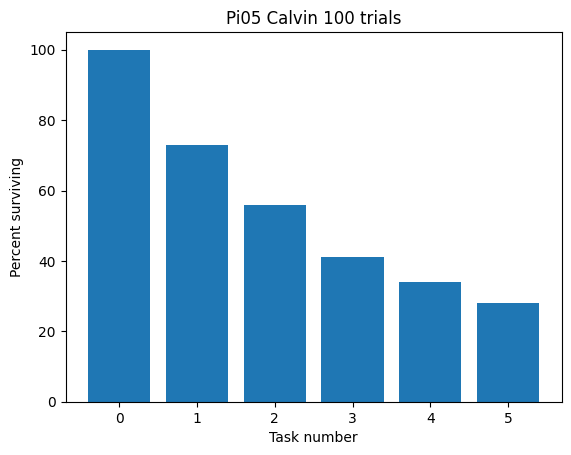

In [38]:
plt.bar(np.arange(6), totals)
plt.ylabel("Percent surviving")
plt.xlabel("Task number")
plt.title("Pi05 Calvin 100 trials")